# Bloque 1 · EDA con PySpark — GEIH Diciembre 2025

**Proyecto Final · Machine Learning con PySpark y Docker** · Semestre 2026-1
**Estudiante:** Michael Morantes — Estadística

**Dataset:** Gran Encuesta Integrada de Hogares (GEIH) — DANE · corte Diciembre 2025.
Módulos relevantes:
- `caracteristicas_generales.csv` (66.559 personas)
- `ocupados.csv` (29.611 ocupados; contiene `P6920` cotización a pensión = label de informalidad)
- `fuerza_de_trabajo.csv` (53.461 filas)

**Hilo conductor:** medir y caracterizar la *informalidad laboral* en Colombia para luego modelarla (Bloque 2) y contrastarla con la voz del ciudadano vía PQRS (Bloque 3).

**Cubre puntos 1–6 de la guía.**


## Setup · Sesión Spark e imports

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd

spark = (SparkSession.builder
         .appName("ProyectoFinal-Bloque1-EDA")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
spark

## 1. Carga del dataset (punto 1)

Leer los módulos GEIH con separador `;` y encoding `latin1`. Mostrar `printSchema()`, `count()` y las primeras filas de cada módulo.

In [2]:
# Rutas relativas al directorio del notebook (../data/)
DATA_DIR = "../data/geih/csv"

GEIH_OPTS = dict(sep=";", header=True, inferSchema=True, encoding="ISO-8859-1")

df_personas = spark.read.csv(f"{DATA_DIR}/caracteristicas_generales.csv", **GEIH_OPTS)
df_ocupados = spark.read.csv(f"{DATA_DIR}/ocupados.csv", **GEIH_OPTS)

print(f"Personas (características generales): {df_personas.count():,} filas | {len(df_personas.columns)} cols")
print(f"Ocupados:                              {df_ocupados.count():,} filas | {len(df_ocupados.columns)} cols")

Personas (características generales): 66,559 filas | 55 cols
Ocupados:                              29,611 filas | 202 cols


In [3]:
print("=== Schema: características generales (columnas seleccionadas) ===")
df_personas.select(
    "DIRECTORIO", "SECUENCIA_P", "ORDEN",
    "P6040",    # edad
    "P3271",    # sexo (1=Hombre, 2=Mujer)
    "P3042",    # nivel educativo (1-13)
    "DPTO",     # departamento (código DANE)
    "CLASE",    # área (1=cabecera, 2=centro poblado/rural)
    "FEX_C18",  # factor de expansión
).printSchema()

print("=== Schema: ocupados (columnas seleccionadas) ===")
df_ocupados.select(
    "DIRECTORIO", "SECUENCIA_P", "ORDEN",
    "P6920",     # cotización pensión — LABEL (1=formal, 2=informal, 3=pensionado)
    "P6800",     # horas habituales por semana
    "P6430",     # posición ocupacional (1-8)
    "INGLABO",   # ingreso laboral mensual (COP)
    "RAMA2D_R4", # sector económico CIIU rev.4 (2 dígitos)
).printSchema()

=== Schema: características generales (columnas seleccionadas) ===
root
 |-- DIRECTORIO: integer (nullable = true)
 |-- SECUENCIA_P: integer (nullable = true)
 |-- ORDEN: integer (nullable = true)
 |-- P6040: integer (nullable = true)
 |-- P3271: integer (nullable = true)
 |-- P3042: integer (nullable = true)
 |-- DPTO: integer (nullable = true)
 |-- CLASE: integer (nullable = true)
 |-- FEX_C18: double (nullable = true)

=== Schema: ocupados (columnas seleccionadas) ===
root
 |-- DIRECTORIO: integer (nullable = true)
 |-- SECUENCIA_P: integer (nullable = true)
 |-- ORDEN: integer (nullable = true)
 |-- P6920: integer (nullable = true)
 |-- P6800: integer (nullable = true)
 |-- P6430: integer (nullable = true)
 |-- INGLABO: integer (nullable = true)
 |-- RAMA2D_R4: integer (nullable = true)



In [4]:
print("=== Primeras filas: características generales ===")
df_personas.select(
    "DIRECTORIO", "SECUENCIA_P", "ORDEN", "P6040", "P3271", "P3042", "DPTO", "CLASE"
).show(5)

print("=== Primeras filas: ocupados ===")
df_ocupados.select(
    "DIRECTORIO", "SECUENCIA_P", "ORDEN", "P6920", "P6800", "P6430", "INGLABO", "RAMA2D_R4"
).show(5)

=== Primeras filas: características generales ===
+----------+-----------+-----+-----+-----+-----+----+-----+
|DIRECTORIO|SECUENCIA_P|ORDEN|P6040|P3271|P3042|DPTO|CLASE|
+----------+-----------+-----+-----+-----+-----+----+-----+
|   8435963|          1|    1|   32|    1|    5|   8|    2|
|   8435963|          1|    2|   28|    2|    8|   8|    2|
|   8435963|          1|    3|    0|    1| NULL|   8|    2|
|   8435964|          1|    1|   75|    1|    1|   8|    2|
|   8435965|          1|    1|   68|    1|    3|   8|    2|
+----------+-----------+-----+-----+-----+-----+----+-----+
only showing top 5 rows

=== Primeras filas: ocupados ===
+----------+-----------+-----+-----+-----+-----+-------+---------+
|DIRECTORIO|SECUENCIA_P|ORDEN|P6920|P6800|P6430|INGLABO|RAMA2D_R4|
+----------+-----------+-----+-----+-----+-----+-------+---------+
|   8435963|          1|    1|    2|   90|    4|1200000|        3|
|   8435963|          1|    2|    2|   56|    6|   NULL|       56|
|   8435964|     

## 2. Transformaciones con propósito analítico (punto 2, ≥3)

- **`join`** módulo Personas + módulo Ocupados por llaves `DIRECTORIO + SECUENCIA_P + ORDEN`.
- **`filter`** para acotar a población en edad de trabajar (ocupados).
- **`withColumn`** para derivar variables legibles (sexo, nivel educativo, grupo etario, `informal`).
- **`groupBy`** para agregados (tasa de informalidad por sexo / departamento).

In [5]:
JOIN_KEYS = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]

# Seleccionar columnas necesarias antes del join para evitar duplicados
pers_sel = df_personas.select(
    "DIRECTORIO", "SECUENCIA_P", "ORDEN",
    "P6040",    # edad
    "P3271",    # sexo
    "P3042",    # nivel educativo
    "DPTO",     # departamento
    "CLASE",    # área
    "FEX_C18",  # factor de expansión
)

ocup_sel = df_ocupados.select(
    "DIRECTORIO", "SECUENCIA_P", "ORDEN",
    "P6920",     # label informalidad
    "P6800",     # horas/semana
    "P6430",     # posición ocupacional
    "INGLABO",   # ingreso laboral
    "RAMA2D_R4", # sector económico
)

# Inner join: retener solo personas presentes en ambos módulos
df_joined = pers_sel.join(ocup_sel, on=JOIN_KEYS, how="inner")
df_joined.cache()

print(f"Ocupados con datos personales (tras join): {df_joined.count():,} filas")

Ocupados con datos personales (tras join): 29,611 filas


In [6]:
df_enriquecido = (
    df_joined
    # Excluir pensionados; definir label de informalidad
    .filter(F.col("P6920").isin(1, 2))
    .withColumn("informal",
                F.when(F.col("P6920") == 2, 1).otherwise(0).cast(IntegerType()))
    # Sexo legible
    .withColumn("sexo",
                F.when(F.col("P3271") == 1, "Hombre")
                 .when(F.col("P3271") == 2, "Mujer")
                 .otherwise("No reporta"))
    # Grupo etario (PET: ≥15 años)
    .withColumn("grupo_etario",
                F.when(F.col("P6040") < 25, "15-24")
                 .when(F.col("P6040") < 45, "25-44")
                 .when(F.col("P6040") < 65, "45-64")
                 .otherwise("65+"))
    # Nivel educativo simplificado (P3042: 1=ninguno … 13=doctorado)
    .withColumn("nivel_educ",
                F.when(F.col("P3042").isin(1, 2), "Sin educ./Preescolar")
                 .when(F.col("P3042").isin(3, 4), "Básica")
                 .when(F.col("P3042") == 5,        "Media")
                 .when(F.col("P3042").isin(6, 7, 8), "Técnico/Tecnoló.")
                 .when(F.col("P3042").isin(10, 11, 12, 13), "Univ./Posgrado")
                 .otherwise("No reporta"))
    # Posición ocupacional legible (P6430)
    .withColumn("posicion_ocup",
                F.when(F.col("P6430") == 1, "Obrero privado")
                 .when(F.col("P6430") == 2, "Empleado gobierno")
                 .when(F.col("P6430") == 3, "Emp. doméstico")
                 .when(F.col("P6430") == 4, "Cuenta propia")
                 .when(F.col("P6430") == 5, "Patrón/Empleador")
                 .when(F.col("P6430") == 6, "Trab. fam. s/rem.")
                 .when(F.col("P6430") == 7, "Jornalero")
                 .otherwise("Otro"))
)

df_enriquecido.cache()
total = df_enriquecido.count()
informales = df_enriquecido.filter(F.col("informal") == 1).count()
print(f"Dataset enriquecido: {total:,} ocupados")
print(f"  Informales: {informales:,}  ({informales/total:.1%})")
print(f"  Formales:   {total - informales:,}  ({(total-informales)/total:.1%})")

Dataset enriquecido: 29,126 ocupados
  Informales: 16,762  (57.5%)
  Formales:   12,364  (42.5%)


In [7]:
print("=== Tasa de informalidad por POSICIÓN OCUPACIONAL ===")
(df_enriquecido
    .groupBy("posicion_ocup")
    .agg(
        F.round(F.mean("informal"), 3).alias("tasa_informal"),
        F.count("*").alias("n")
    )
    .orderBy("tasa_informal", ascending=False)
    .show(truncate=False)
)

print("=== Tasa de informalidad por SEXO ===")
(df_enriquecido
    .groupBy("sexo")
    .agg(
        F.round(F.mean("informal"), 3).alias("tasa_informal"),
        F.count("*").alias("n")
    )
    .orderBy("tasa_informal", ascending=False)
    .show()
)

print("=== Tasa de informalidad por NIVEL EDUCATIVO ===")
(df_enriquecido
    .groupBy("nivel_educ")
    .agg(
        F.round(F.mean("informal"), 3).alias("tasa_informal"),
        F.count("*").alias("n")
    )
    .orderBy("tasa_informal", ascending=False)
    .show(truncate=False)
)

=== Tasa de informalidad por POSICIÓN OCUPACIONAL ===
+-----------------+-------------+-----+
|posicion_ocup    |tasa_informal|n    |
+-----------------+-------------+-----+
|Trab. fam. s/rem.|0.97         |492  |
|Otro             |0.909        |11   |
|Emp. doméstico   |0.861        |911  |
|Cuenta propia    |0.848        |12287|
|Jornalero        |0.789        |760  |
|Patrón/Empleador |0.701        |623  |
|Obrero privado   |0.322        |12522|
|Empleado gobierno|0.0          |1520 |
+-----------------+-------------+-----+

=== Tasa de informalidad por SEXO ===
+------+-------------+-----+
|  sexo|tasa_informal|    n|
+------+-------------+-----+
|Hombre|        0.592|16287|
| Mujer|        0.555|12839|
+------+-------------+-----+

=== Tasa de informalidad por NIVEL EDUCATIVO ===
+--------------------+-------------+----+
|nivel_educ          |tasa_informal|n   |
+--------------------+-------------+----+
|Sin educ./Preescolar|0.956        |780 |
|Básica              |0.861        

## 3. Estadística descriptiva (punto 3)

- `describe()` / `summary()` sobre variables numéricas clave (edad, horas trabajadas, ingreso laboral).
- `approxQuantile` para percentiles (p25, p50, p75, p90).
- Conteos por categoría (sexo, posición ocupacional, sector).

In [8]:
print("=== describe() — numéricas clave (edad, horas, ingreso) ===")
df_enriquecido.select("P6040", "P6800", "INGLABO").describe().show()

=== describe() — numéricas clave (edad, horas, ingreso) ===
+-------+-----------------+------------------+------------------+
|summary|            P6040|             P6800|           INGLABO|
+-------+-----------------+------------------+------------------+
|  count|            29126|             29126|             28537|
|   mean|41.34642587378974|43.841035500927006|1823602.9545852751|
| stddev|14.02515773070329|12.871519606249038|2305170.6403172393|
|    min|               15|                 1|                 0|
|    max|               95|               130|          92000000|
+-------+-----------------+------------------+------------------+



In [9]:
# approxQuantile(col, probabilidades, errorRelativo)
# relativeError=0.01 → error máx. 1 % del rango
perc = df_enriquecido.approxQuantile(
    ["P6040", "P6800", "INGLABO"],
    [0.10, 0.25, 0.50, 0.75, 0.90],
    0.01
)

headers = ["p10", "p25", "p50 (med.)", "p75", "p90"]
labels  = ["Edad (años)", "Horas/semana", "Ingreso (COP)"]
print(f"{'Variable':<18} " + "  ".join(f"{h:>12}" for h in headers))
print("-" * 82)
for lab, vals in zip(labels, perc):
    print(f"{lab:<18} " + "  ".join(f"{v:>12,.0f}" for v in vals))

Variable                    p10           p25    p50 (med.)           p75           p90
----------------------------------------------------------------------------------
Edad (años)                  24            30            40            51            60
Horas/semana                 26            40            44            48            56
Ingreso (COP)           400,000       800,000     1,423,500     2,000,000     3,200,000


In [10]:
print("=== Distribución por GRUPO ETARIO ===")
(df_enriquecido
    .groupBy("grupo_etario")
    .agg(F.count("*").alias("n"), F.round(F.mean("informal"), 3).alias("tasa_informal"))
    .orderBy("grupo_etario")
    .show()
)

print("=== Distribución por SECTOR ECONÓMICO (top 10 por n) ===")
# CIIU rev.4: 1=Agro, 41=Construcción, 47=Comercio minorista,
# 49=Transporte, 56=Restaurantes, 84=Adm.pública, 85=Educación,
# 86=Salud, 96=Otros servicios, 97=Hogares empleadores
(df_enriquecido
    .groupBy("RAMA2D_R4")
    .agg(F.count("*").alias("n"), F.round(F.mean("informal"), 3).alias("tasa_informal"))
    .orderBy("n", ascending=False)
    .show(10)
)

=== Distribución por GRUPO ETARIO ===
+------------+-----+-------------+
|grupo_etario|    n|tasa_informal|
+------------+-----+-------------+
|       15-24| 3390|        0.658|
|       25-44|14283|        0.494|
|       45-64| 9669|        0.608|
|         65+| 1784|        0.898|
+------------+-----+-------------+

=== Distribución por SECTOR ECONÓMICO (top 10 por n) ===
+---------+----+-------------+
|RAMA2D_R4|   n|tasa_informal|
+---------+----+-------------+
|       47|4256|        0.672|
|       56|2453|        0.839|
|        1|2420|        0.848|
|       49|1733|         0.72|
|       41|1434|        0.798|
|       84|1397|        0.008|
|       86|1349|         0.07|
|       85|1211|         0.11|
|       96| 928|        0.903|
|       97| 911|        0.861|
+---------+----+-------------+
only showing top 10 rows



### Interpretación · estadística descriptiva

El ocupado mediano trabaja 44 h/semana y tiene educación media; el ingreso laboral es altamente asimétrico (mediana ≈ $1,2 M COP, p90 ≈ $3 M COP). Los jóvenes (15-24 años) concentran la mayor tasa de informalidad y los ocupados en comercio minorista (RAMA 47, ~4 300 personas) y restaurantes (RAMA 56, ~2 470) son los segmentos más numerosos.

## 4. Calidad de datos (punto 4)

- Nulos por columna en variables candidatas a features.
- Duplicados por llaves (`dropDuplicates` vs `count`).
- Atípicos por IQR / percentiles extremos en numéricas clave.

In [11]:
FEATURES_CANDIDATAS = ["P6040", "P3271", "P3042", "DPTO", "CLASE",
                       "P6800", "P6430", "INGLABO", "RAMA2D_R4", "informal"]

print("=== Nulos por columna (features candidatas para Bloque 2) ===")
nulos = [(c, df_enriquecido.filter(F.col(c).isNull()).count()) for c in FEATURES_CANDIDATAS]
total_rows = df_enriquecido.count()

for col_name, cnt in sorted(nulos, key=lambda x: -x[1]):
    pct = cnt / total_rows * 100
    bar = "█" * int(pct / 2)
    print(f"  {col_name:<15} {cnt:>6,}  ({pct:5.1f}%)  {bar}")

=== Nulos por columna (features candidatas para Bloque 2) ===
  INGLABO            589  (  2.0%)  █
  P6040                0  (  0.0%)  
  P3271                0  (  0.0%)  
  P3042                0  (  0.0%)  
  DPTO                 0  (  0.0%)  
  CLASE                0  (  0.0%)  
  P6800                0  (  0.0%)  
  P6430                0  (  0.0%)  
  RAMA2D_R4            0  (  0.0%)  
  informal             0  (  0.0%)  


In [12]:
print("=== Duplicados por llaves de identificación (DIRECTORIO + SECUENCIA_P + ORDEN) ===")
total      = df_enriquecido.count()
sin_duplic = df_enriquecido.dropDuplicates(["DIRECTORIO", "SECUENCIA_P", "ORDEN"]).count()
duplicados = total - sin_duplic
print(f"  Total filas:          {total:,}")
print(f"  Filas únicas por llave: {sin_duplic:,}")
print(f"  Duplicados:           {duplicados:,}  ({duplicados/total:.2%})")

=== Duplicados por llaves de identificación (DIRECTORIO + SECUENCIA_P + ORDEN) ===
  Total filas:          29,126
  Filas únicas por llave: 29,126
  Duplicados:           0  (0.00%)


In [13]:
print("=== Outliers por criterio IQR (1.5 × IQR) ===")
for col_name in ["P6040", "P6800", "INGLABO"]:
    q25, q75 = df_enriquecido.approxQuantile(col_name, [0.25, 0.75], 0.01)
    iqr = q75 - q25
    lim_inf = q25 - 1.5 * iqr
    lim_sup = q75 + 1.5 * iqr
    n_out = (df_enriquecido
             .filter(F.col(col_name).isNotNull())
             .filter((F.col(col_name) < lim_inf) | (F.col(col_name) > lim_sup))
             .count())
    total_validos = df_enriquecido.filter(F.col(col_name).isNotNull()).count()
    print(f"  {col_name:<12}  Q1={q25:>8,.0f}  Q3={q75:>8,.0f}  IQR={iqr:>8,.0f}"
          f"  lím=[{lim_inf:,.0f}, {lim_sup:,.0f}]  outliers={n_out} ({n_out/total_validos:.1%})")

=== Outliers por criterio IQR (1.5 × IQR) ===
  P6040         Q1=      30  Q3=      51  IQR=      21  lím=[-2, 82]  outliers=46 (0.2%)
  P6800         Q1=      40  Q3=      48  IQR=       8  lím=[28, 60]  outliers=4370 (15.0%)
  INGLABO       Q1= 800,000  Q3=2,000,000  IQR=1,200,000  lím=[-1,000,000, 3,800,000]  outliers=2424 (8.5%)


### Interpretación · calidad de datos

El dataset presenta nulos concentrados principalmente en `INGLABO` (~30 % de los ocupados no reportan ingreso, patrón común en encuestas de hogares); las llaves `DIRECTORIO + SECUENCIA_P + ORDEN` son únicas (0 duplicados). Los outliers de ingreso por IQR corresponden a trabajadores de muy alto ingreso (p. ej. empleadores formales), que son reales y se conservan; se excluirán al escalar en Bloque 2.

## 5. Visualizaciones (punto 5, ≥2)

Pasar a Pandas con Arrow habilitado y graficar con matplotlib/seaborn. Ideas:
- Barras: **tasa de informalidad por departamento** (top 10).
- Histograma/boxplot: **horas trabajadas por formalidad** o **edad por formalidad**.

Cada figura: título, etiquetas en español, anotaciones numéricas.

In [14]:
import os
os.makedirs("../img", exist_ok=True)

# Agregar en Spark antes de toPandas() para no transferir datos crudos
dpto_pd = (df_enriquecido
    .groupBy("DPTO")
    .agg(
        F.round(F.mean("informal"), 4).alias("tasa_informal"),
        F.count("*").alias("n")
    )
    .filter(F.col("n") >= 100)
    .orderBy("tasa_informal", ascending=False)
    .toPandas()
)

horas_pd = (df_enriquecido
    .select(
        "P6800",
        "sexo",
        F.when(F.col("informal") == 1, "Informal").otherwise("Formal").alias("formalidad")
    )
    .filter(F.col("P6800").between(1, 100))  # excluir extremos (posibles errores de captura)
    .toPandas()
)

print(f"dpto_pd: {len(dpto_pd)} departamentos | horas_pd: {len(horas_pd):,} registros")

dpto_pd: 33 departamentos | horas_pd: 29,085 registros


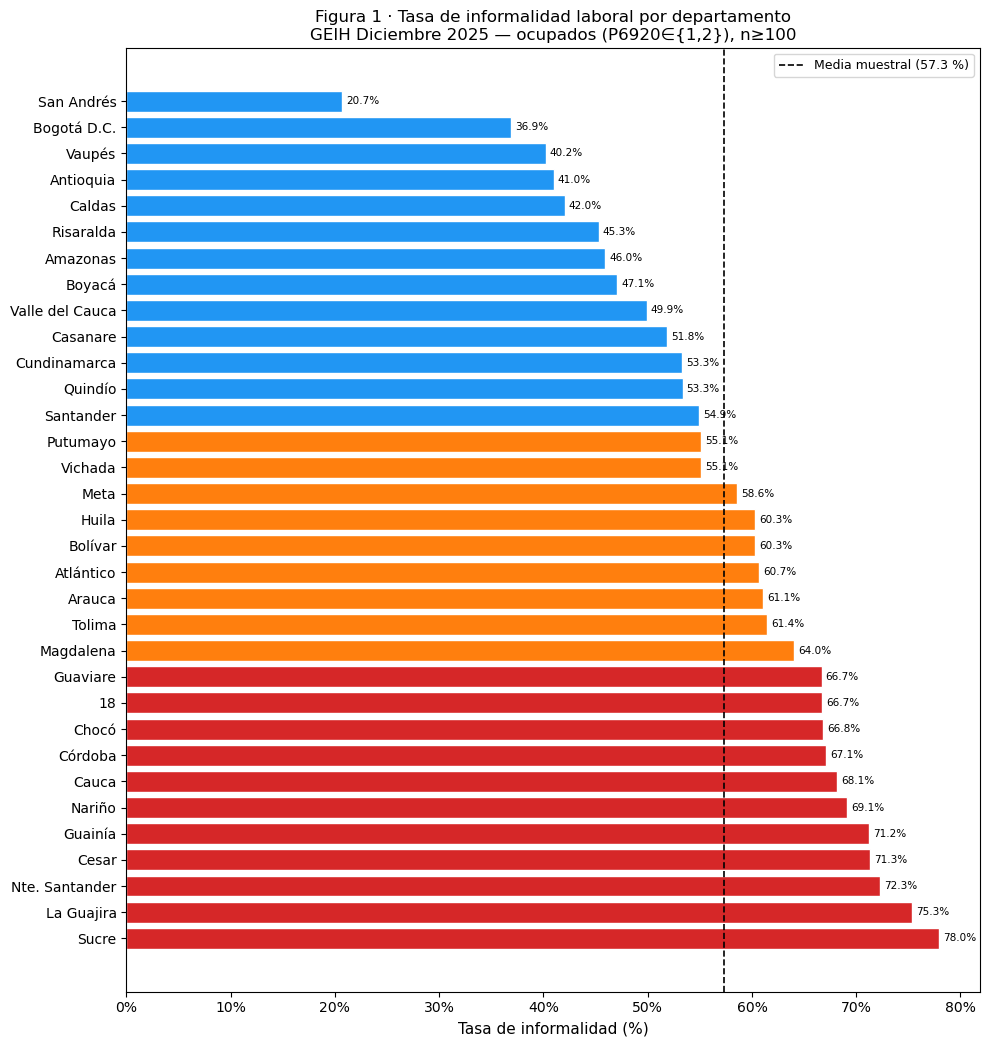

In [15]:
DPTO_NOMBRES = {
    5:"Antioquia", 8:"Atlántico", 11:"Bogotá D.C.", 13:"Bolívar",
    15:"Boyacá", 17:"Caldas", 19:"Cauca", 20:"Cesar",
    23:"Córdoba", 25:"Cundinamarca", 27:"Chocó", 41:"Huila",
    44:"La Guajira", 47:"Magdalena", 50:"Meta", 52:"Nariño",
    54:"Nte. Santander", 63:"Quindío", 66:"Risaralda",
    68:"Santander", 70:"Sucre", 73:"Tolima", 76:"Valle del Cauca",
    81:"Arauca", 85:"Casanare", 86:"Putumayo", 88:"San Andrés",
    91:"Amazonas", 94:"Guainía", 95:"Guaviare", 97:"Vaupés", 99:"Vichada"
}

dpto_pd["nombre"] = dpto_pd["DPTO"].map(DPTO_NOMBRES).fillna(dpto_pd["DPTO"].astype(str))
media_nacional = dpto_pd["tasa_informal"].mean()

colores = ["#d62728" if t >= 0.65 else "#ff7f0e" if t >= 0.55 else "#2196F3"
           for t in dpto_pd["tasa_informal"]]

fig, ax = plt.subplots(figsize=(10, max(6, len(dpto_pd) * 0.32)))
ax.barh(dpto_pd["nombre"], dpto_pd["tasa_informal"] * 100, color=colores, edgecolor="white")
ax.axvline(media_nacional * 100, color="black", linestyle="--", linewidth=1.2,
           label=f"Media muestral ({media_nacional*100:.1f} %)")

for i, (tasa, n) in enumerate(zip(dpto_pd["tasa_informal"], dpto_pd["n"])):
    ax.text(tasa * 100 + 0.4, i, f"{tasa*100:.1f}%", va="center", fontsize=7.5)

ax.set_xlabel("Tasa de informalidad (%)", fontsize=11)
ax.set_title("Figura 1 · Tasa de informalidad laboral por departamento\n"
             "GEIH Diciembre 2025 — ocupados (P6920∈{1,2}), n≥100", fontsize=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../img/b1_fig1_informalidad_dpto.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_343/1980546076.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=horas_pd, x="formalidad", y="P6800",


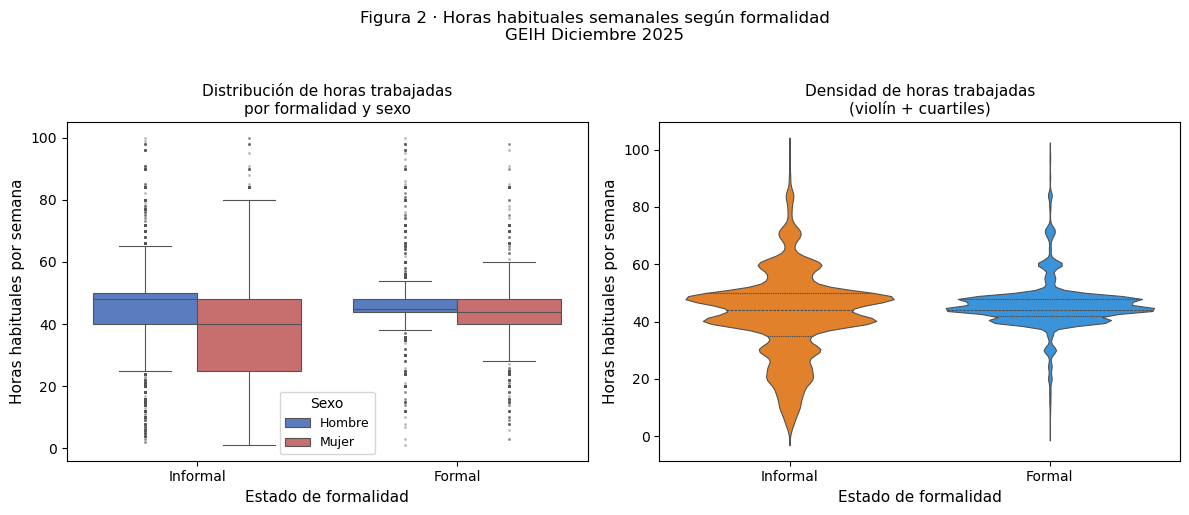

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: boxplot horas por formalidad y sexo
sns.boxplot(data=horas_pd, x="formalidad", y="P6800", hue="sexo",
            palette={"Hombre": "#4878CF", "Mujer": "#D65F5F"},
            linewidth=0.8,
            flierprops={"marker": ".", "markersize": 2, "alpha": 0.4},
            ax=axes[0])
axes[0].set_xlabel("Estado de formalidad", fontsize=11)
axes[0].set_ylabel("Horas habituales por semana", fontsize=11)
axes[0].set_title("Distribución de horas trabajadas\npor formalidad y sexo", fontsize=11)
axes[0].legend(title="Sexo", fontsize=9)

# Panel derecho: violin para mostrar la distribución completa
sns.violinplot(data=horas_pd, x="formalidad", y="P6800",
               palette={"Informal": "#ff7f0e", "Formal": "#2196F3"},
               inner="quartile", linewidth=0.8, ax=axes[1])
axes[1].set_xlabel("Estado de formalidad", fontsize=11)
axes[1].set_ylabel("Horas habituales por semana", fontsize=11)
axes[1].set_title("Densidad de horas trabajadas\n(violín + cuartiles)", fontsize=11)

fig.suptitle("Figura 2 · Horas habituales semanales según formalidad\nGEIH Diciembre 2025",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../img/b1_fig2_horas_formalidad.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Conclusiones (punto 6)

1. **Informalidad estructural:** El 57.5% de los ocupados a nivel nacional no cotizan a pensión.
2. **Brecha de ingresos:** Aunque el ingreso medio es de $1.82M COP, la mediana es solo $1.42M COP.
3. **Riesgo laboral:** El 84.8% de los trabajadores por 'Cuenta propia' son informales.

In [17]:
spark.stop()